In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine

sns.set_theme(style="whitegrid")

### Section 1: Auto-Discover All Attack CSV Pairs

In [2]:
asv_dir = Path("/home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/asvspoof5/output")

bonafide_files = sorted(asv_dir.glob("*_bonafide.csv"))
pairs = []
for bf_path in bonafide_files:
    spoof_path = bf_path.parent / bf_path.name.replace("_bonafide.csv", ".csv")
    if spoof_path.exists():
        parts = bf_path.stem.replace("_bonafide", "").split("_")
        attack_id = parts[-1]  
        partition = parts[-2] if len(parts) >= 2 else ""  # e.g. 'dev' or 'train'
        label = f"{partition}_{attack_id}"
        pairs.append({"label": label, "attack_id": attack_id, "partition": partition,
                       "spoof_path": spoof_path, "bonafide_path": bf_path})

print(f"Found {len(pairs)} attack pairs:")
for p in pairs:
    print(f"  {p['label']}: {p['spoof_path'].name} vs {p['bonafide_path'].name}")

Found 16 attack pairs:
  dev_A09: tcav_dev_A09.csv vs tcav_dev_A09_bonafide.csv
  dev_A10: tcav_dev_A10.csv vs tcav_dev_A10_bonafide.csv
  dev_A11: tcav_dev_A11.csv vs tcav_dev_A11_bonafide.csv
  dev_A12: tcav_dev_A12.csv vs tcav_dev_A12_bonafide.csv
  dev_A13: tcav_dev_A13.csv vs tcav_dev_A13_bonafide.csv
  dev_A14: tcav_dev_A14.csv vs tcav_dev_A14_bonafide.csv
  dev_A15: tcav_dev_A15.csv vs tcav_dev_A15_bonafide.csv
  dev_A16: tcav_dev_A16.csv vs tcav_dev_A16_bonafide.csv
  train_A01: tcav_train_A01.csv vs tcav_train_A01_bonafide.csv
  train_A02: tcav_train_A02.csv vs tcav_train_A02_bonafide.csv
  train_A03: tcav_train_A03.csv vs tcav_train_A03_bonafide.csv
  train_A04: tcav_train_A04.csv vs tcav_train_A04_bonafide.csv
  train_A05: tcav_train_A05.csv vs tcav_train_A05_bonafide.csv
  train_A06: tcav_train_A06.csv vs tcav_train_A06_bonafide.csv
  train_A07: tcav_train_A07.csv vs tcav_train_A07_bonafide.csv
  train_A08: tcav_train_A08.csv vs tcav_train_A08_bonafide.csv


### Section 2: Compute Metrics for All Attacks

In [3]:
summary_rows = []
all_deltas = {}  # attack_label -> {concept_name: delta_sign_count}
all_deltas_mag = {}  # attack_label -> {concept_name: delta_magnitude}

for pair in pairs:
    df_spoof = pd.read_csv(pair["spoof_path"])
    df_bonafide = pd.read_csv(pair["bonafide_path"])

    # Sort consistently
    df_spoof = df_spoof.sort_values("concept_name").reset_index(drop=True)
    df_bonafide = df_bonafide.sort_values("concept_name").reset_index(drop=True)

    # Cosine similarities
    v_s_sc = df_spoof["sign_count"].values
    v_b_sc = df_bonafide["sign_count"].values
    cos_raw = 1 - cosine(v_s_sc, v_b_sc)

    v_s_centered = v_s_sc * 2 - 1
    v_b_centered = v_b_sc * 2 - 1
    cos_centered = 1 - cosine(v_s_centered, v_b_centered)

    v_s_mag = df_spoof["magnitude"].values
    v_b_mag = df_bonafide["magnitude"].values
    cos_mag = 1 - cosine(v_s_mag, v_b_mag)

    # Per-concept deltas
    merged = df_spoof.merge(df_bonafide, on="concept_name", suffixes=("_spoof", "_bonafide"))
    merged["delta_sc"] = merged["sign_count_spoof"] - merged["sign_count_bonafide"]
    merged["delta_mag"] = merged["magnitude_spoof"] - merged["magnitude_bonafide"]

    top_changed = merged.loc[merged["delta_sc"].abs().idxmax(), "concept_name"]
    top_preserved = merged.loc[merged["delta_sc"].abs().idxmin(), "concept_name"]
    n_flipped = int((np.sign(merged["magnitude_spoof"]) != np.sign(merged["magnitude_bonafide"])).sum())

    summary_rows.append({
        "attack": pair["label"],
        "cos_sc_raw": round(cos_raw, 4),
        "cos_sc_centered": round(cos_centered, 4),
        "cos_magnitude": round(cos_mag, 4),
        "top_changed": top_changed,
        "top_preserved": top_preserved,
        "n_mag_flipped": n_flipped,
    })

    all_deltas[pair["label"]] = dict(zip(merged["concept_name"], merged["delta_sc"]))
    all_deltas_mag[pair["label"]] = dict(zip(merged["concept_name"], merged["delta_mag"]))

summary_df = pd.DataFrame(summary_rows).set_index("attack")
print("\n=== Summary Table ===")
display(summary_df)


=== Summary Table ===


,cos_sc_raw,cos_sc_centered,cos_magnitude,top_changed,top_preserved,n_mag_flipped
attack,,,,,,
dev_A09,0.9993,0.9744,0.9882,long_rising_steep_thin,long_dropping_flat_thick,0
dev_A10,0.9991,0.9725,0.9896,long_constant_thick,long_dropping_flat_thick,0
dev_A11,0.9992,0.9925,0.9922,short_constant_thick,long_rising_steep_thick,0
dev_A12,0.9987,0.0651,0.0581,long_rising_steep_thick,short_constant_thick,6
dev_A13,0.9955,-0.6175,-0.5737,long_rising_flat_thick,long_dropping_flat_thick,11
dev_A14,0.9989,0.9652,0.8797,long_constant_thick,long_dropping_flat_thick,1
dev_A15,0.9995,0.9967,0.9989,long_constant_thick,short_dropping_steep_thick,0
dev_A16,0.9972,0.9588,0.9729,long_dropping_flat_thick,short_rising_steep_thin,0
train_A01,0.9964,0.9347,0.9498,long_rising_flat_thick,long_dropping_flat_thick,0


### Section 3: Cosine Similarity Comparison Across Attacks

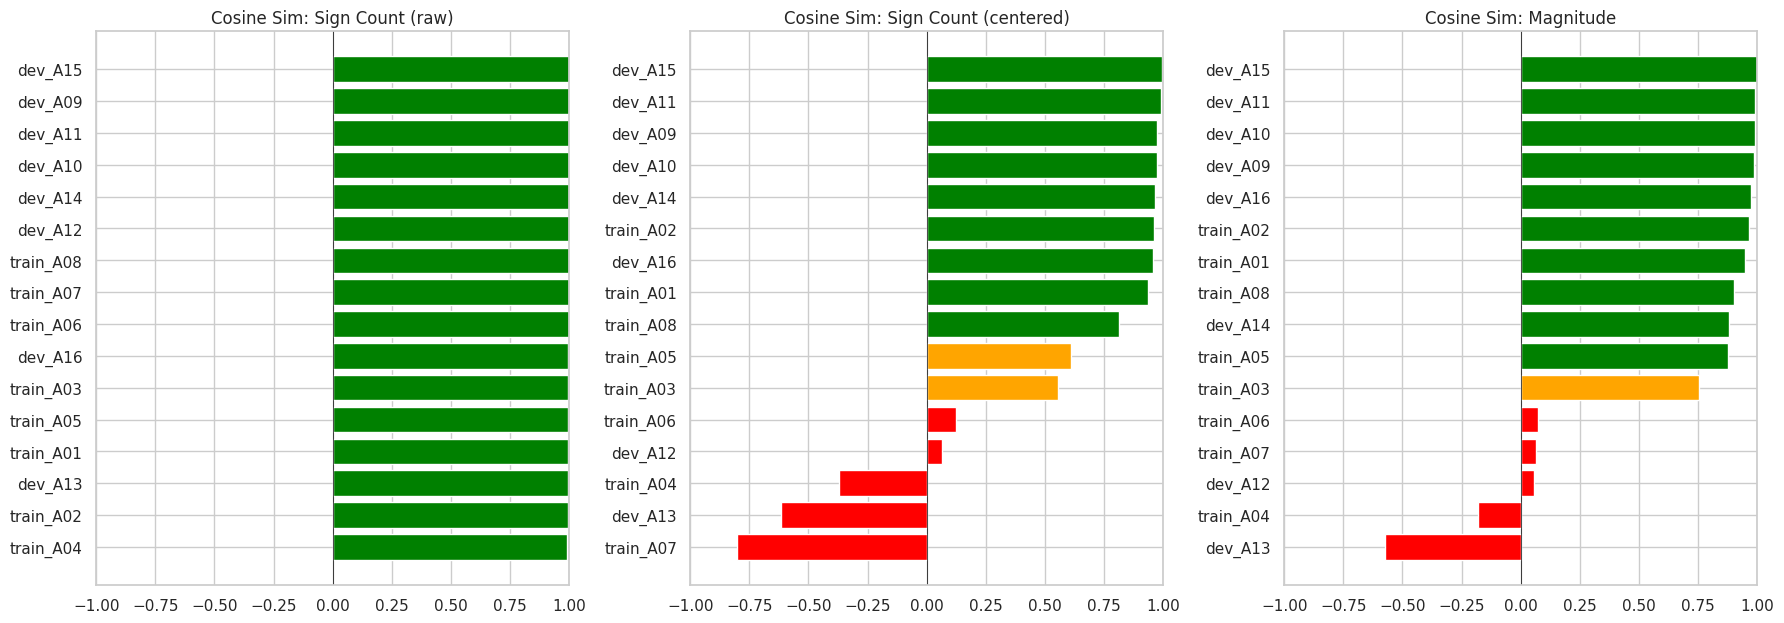

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, max(5, len(pairs) * 0.4)))

for ax, col, title in zip(axes, 
    ["cos_sc_raw", "cos_sc_centered", "cos_magnitude"],
    ["Sign Count (raw)", "Sign Count (centered)", "Magnitude"]):
    vals = summary_df[col].sort_values()
    colors = ["green" if v > 0.8 else "orange" if v > 0.5 else "red" for v in vals]
    ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(f"Cosine Sim: {title}")
    ax.set_xlim(-1, 1)
    ax.axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

### Section 4: Sign Count Delta Heatmap (All Attacks x Concepts)

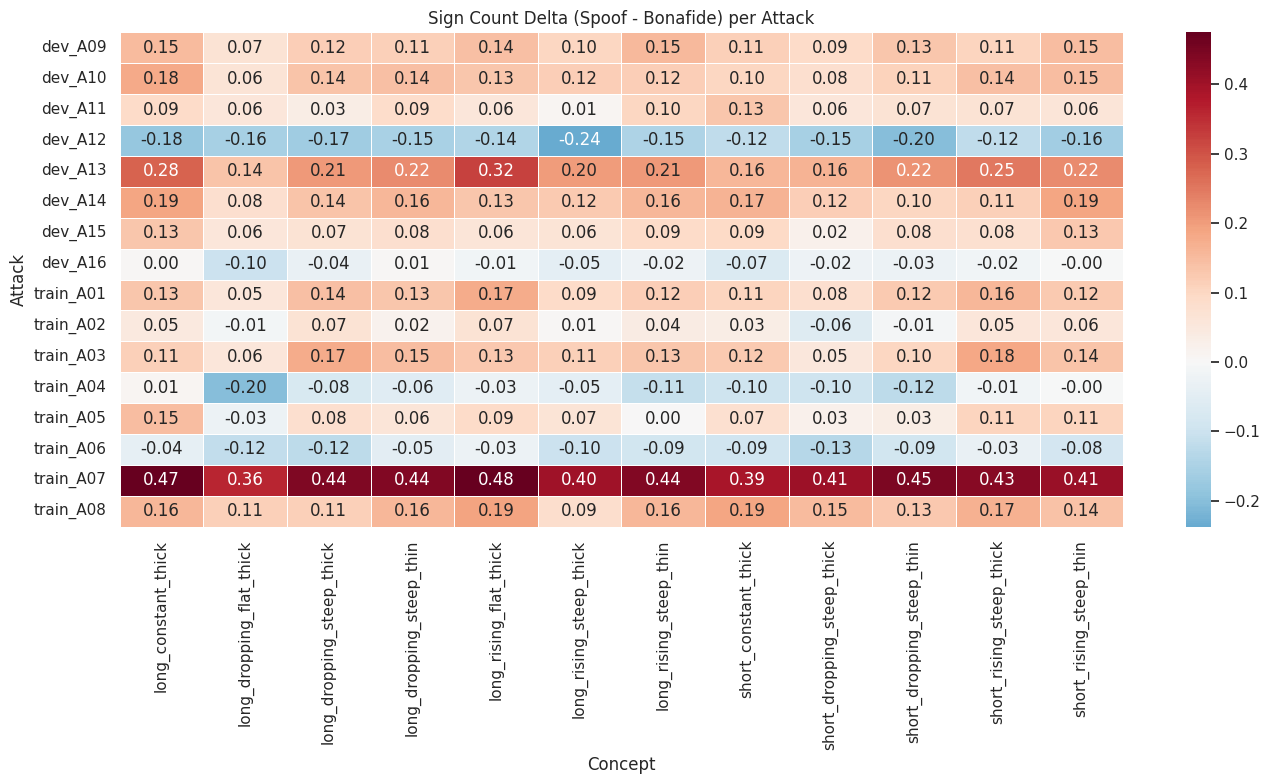

In [5]:
delta_sc_df = pd.DataFrame(all_deltas).T.sort_index()

plt.figure(figsize=(14, max(5, len(pairs) * 0.5)))
sns.heatmap(delta_sc_df, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Sign Count Delta (Spoof - Bonafide) per Attack")
plt.xlabel("Concept")
plt.ylabel("Attack")
plt.tight_layout()
plt.show()

### Section 5: Magnitude Delta Heatmap (All Attacks x Concepts)

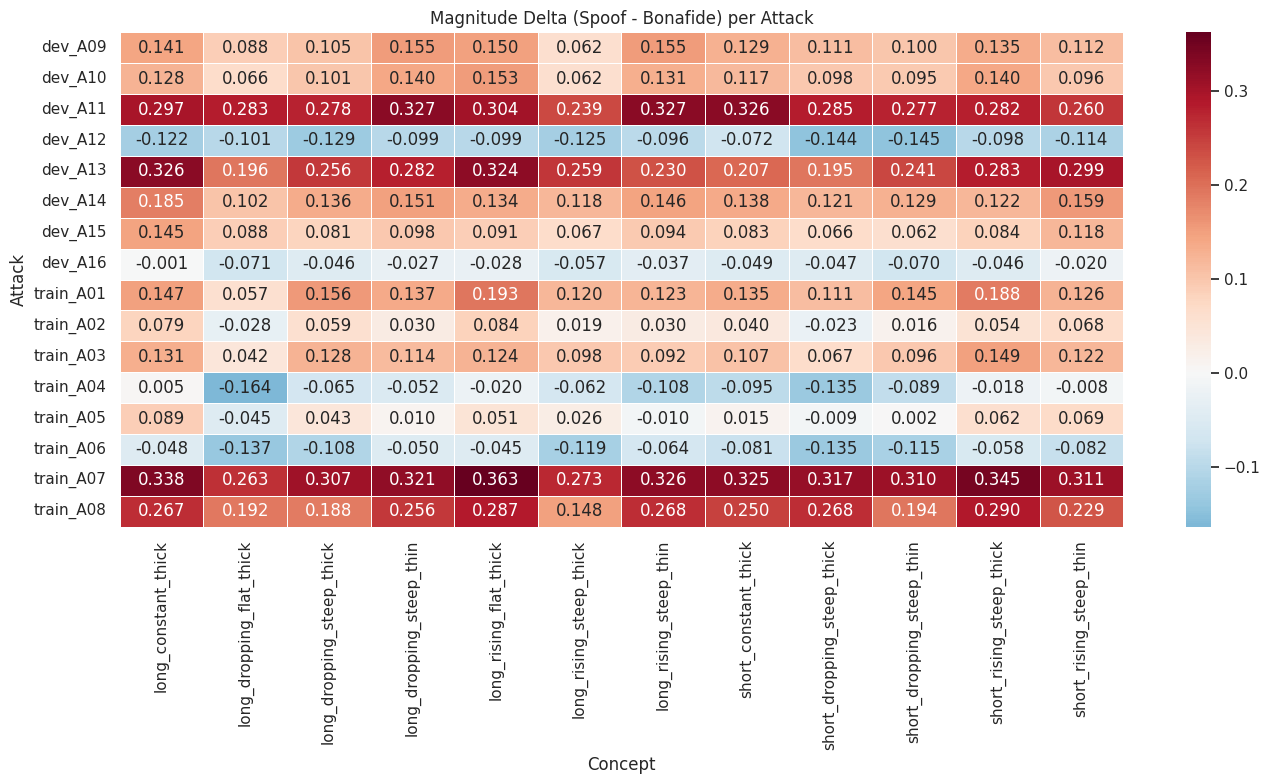

In [6]:
delta_mag_df = pd.DataFrame(all_deltas_mag).T.sort_index()

plt.figure(figsize=(14, max(5, len(pairs) * 0.5)))
sns.heatmap(delta_mag_df, cmap="RdBu_r", center=0, annot=True, fmt=".3f", linewidths=0.5)
plt.title("Magnitude Delta (Spoof - Bonafide) per Attack")
plt.xlabel("Concept")
plt.ylabel("Attack")
plt.tight_layout()
plt.show()

### Section 6: Per-Attack Diverging Bar Charts

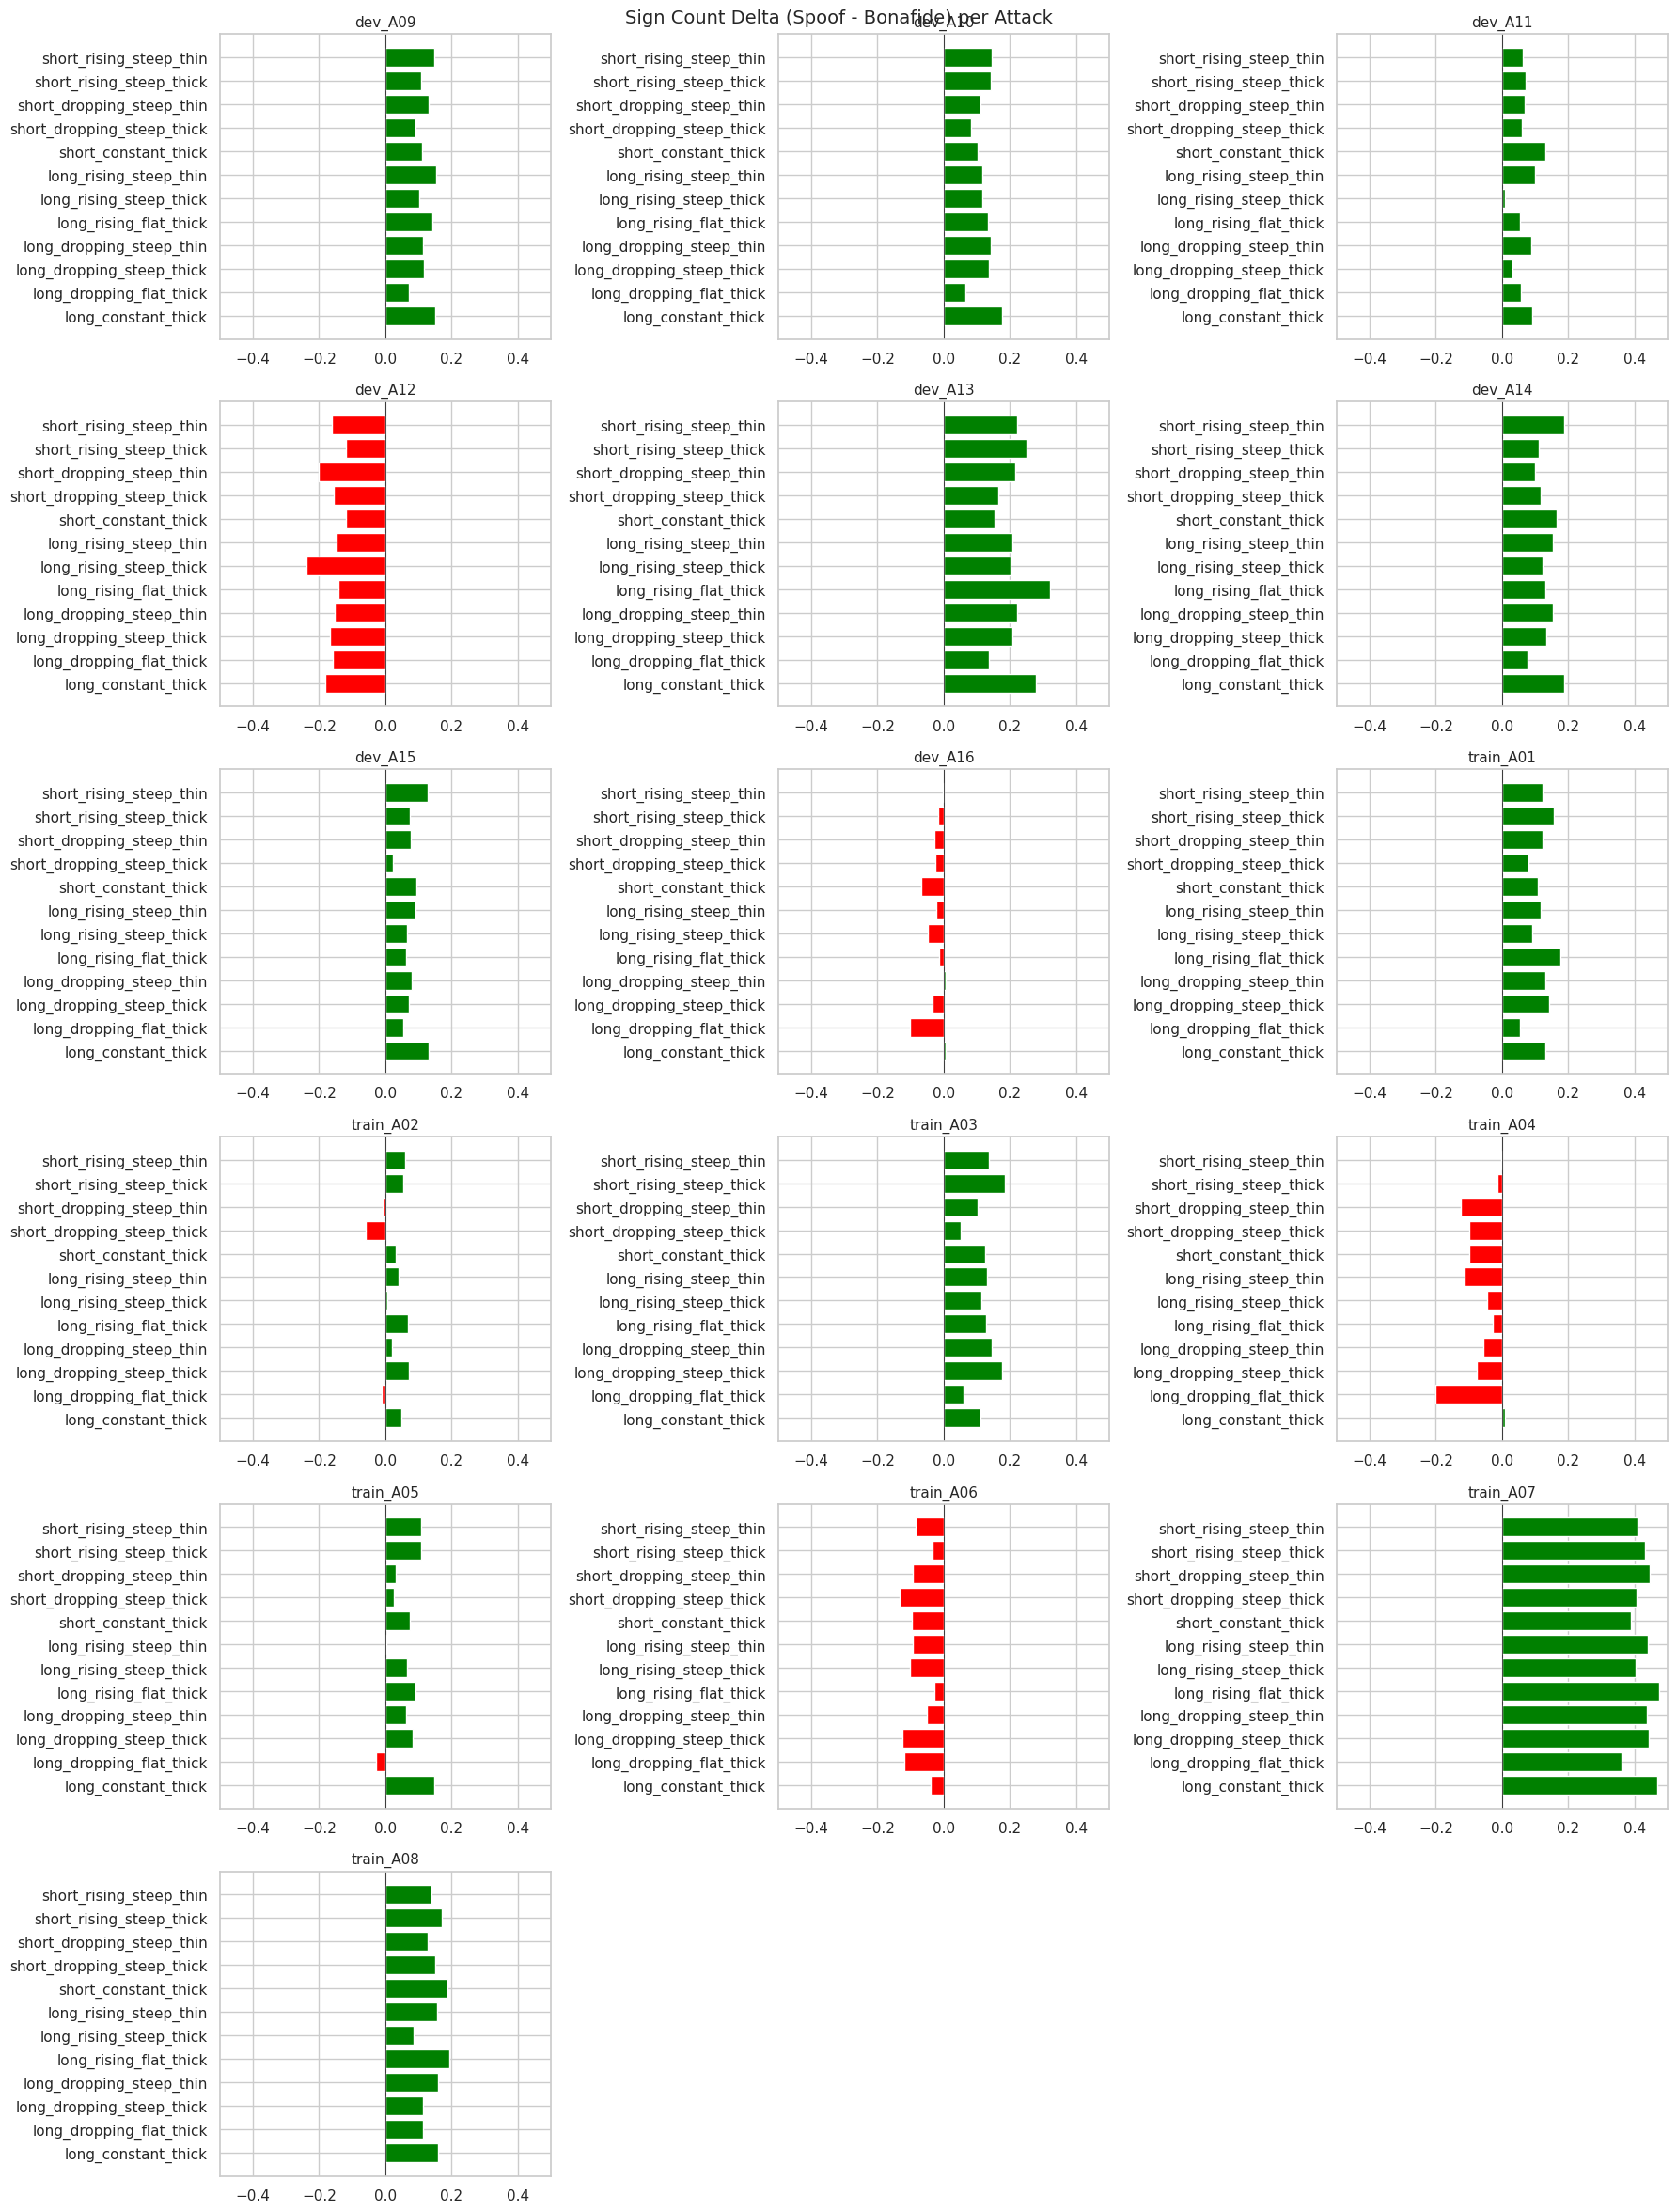

In [12]:
n_attacks = len(pairs)
n_cols = 3
n_rows = int(np.ceil(n_attacks / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows), squeeze=False)

for idx, pair in enumerate(pairs):
    ax = axes[idx // n_cols][idx % n_cols]
    deltas = pd.Series(all_deltas[pair["label"]])
    colors = ["red" if v < 0 else "green" for v in deltas]
    ax.barh(deltas.index, deltas.values, color=colors)
    ax.set_title(pair["label"], fontsize=11)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlim(-0.5, 0.5)

for idx in range(len(pairs), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis("off")

fig.suptitle("Sign Count Delta (Spoof - Bonafide) per Attack", fontsize=14)
plt.tight_layout()
plt.show()

### Section 7: Shared vs Distinctive Concepts (All Attacks)

In [8]:
threshold = 0.7
shared_counts = {}  # concept -> how many attacks share it as strong in both
distinctive_counts = {}  # concept -> how many attacks have it strong in only one side

for pair in pairs:
    df_spoof = pd.read_csv(pair["spoof_path"]).sort_values("concept_name")
    df_bonafide = pd.read_csv(pair["bonafide_path"]).sort_values("concept_name")
    merged = df_spoof.merge(df_bonafide, on="concept_name", suffixes=("_spoof", "_bonafide"))

    for _, row in merged.iterrows():
        concept = row["concept_name"]
        strong_spoof = row["sign_count_spoof"] > threshold
        strong_bonafide = row["sign_count_bonafide"] > threshold
        if strong_spoof and strong_bonafide:
            shared_counts[concept] = shared_counts.get(concept, 0) + 1
        elif strong_spoof != strong_bonafide:
            distinctive_counts[concept] = distinctive_counts.get(concept, 0) + 1

print(f"Concepts most often SHARED as strong (threshold > {threshold}):")
for concept, count in sorted(shared_counts.items(), key=lambda x: -x[1]):
    print(f"  {concept}: shared in {count}/{len(pairs)} attacks")

print(f"\nConcepts most often DISTINCTIVE (threshold > {threshold}):")
for concept, count in sorted(distinctive_counts.items(), key=lambda x: -x[1]):
    print(f"  {concept}: distinctive in {count}/{len(pairs)} attacks")

Concepts most often SHARED as strong (threshold > 0.7):
  long_rising_flat_thick: shared in 4/16 attacks
  short_rising_steep_thick: shared in 4/16 attacks
  long_constant_thick: shared in 2/16 attacks
  long_dropping_flat_thick: shared in 2/16 attacks
  long_dropping_steep_thick: shared in 2/16 attacks
  long_dropping_steep_thin: shared in 2/16 attacks
  long_rising_steep_thick: shared in 2/16 attacks
  long_rising_steep_thin: shared in 2/16 attacks
  short_rising_steep_thin: shared in 2/16 attacks
  short_constant_thick: shared in 1/16 attacks
  short_dropping_steep_thick: shared in 1/16 attacks

Concepts most often DISTINCTIVE (threshold > 0.7):
  short_constant_thick: distinctive in 5/16 attacks
  long_constant_thick: distinctive in 4/16 attacks
  long_dropping_steep_thin: distinctive in 4/16 attacks
  long_rising_steep_thick: distinctive in 4/16 attacks
  long_rising_steep_thin: distinctive in 4/16 attacks
  short_rising_steep_thin: distinctive in 4/16 attacks
  long_dropping_flat

### Section 8: Overall Summary

In [9]:
print("=== Overall Summary ===")
print(f"\nTotal attack pairs analyzed: {len(pairs)}")
print(f"\nMean cosine similarity (sign_count raw):      {summary_df['cos_sc_raw'].mean():.4f}")
print(f"Mean cosine similarity (sign_count centered):  {summary_df['cos_sc_centered'].mean():.4f}")
print(f"Mean cosine similarity (magnitude):            {summary_df['cos_magnitude'].mean():.4f}")

print(f"\nMost similar to bonafide (centered): {summary_df['cos_sc_centered'].idxmax()} ({summary_df['cos_sc_centered'].max():.4f})")
print(f"Least similar to bonafide (centered): {summary_df['cos_sc_centered'].idxmin()} ({summary_df['cos_sc_centered'].min():.4f})")

print(f"\nAttacks with most magnitude flips:")
for attack, row in summary_df.nlargest(3, "n_mag_flipped").iterrows():
    print(f"  {attack}: {int(row['n_mag_flipped'])} concepts flipped")

# Global concept that changed most across all attacks
mean_abs_delta = delta_sc_df.abs().mean(axis=0).sort_values(ascending=False)
print(f"\nConcept most changed across all attacks: {mean_abs_delta.index[0]} (mean |delta| = {mean_abs_delta.iloc[0]:.4f})")
print(f"Concept most preserved across all attacks: {mean_abs_delta.index[-1]} (mean |delta| = {mean_abs_delta.iloc[-1]:.4f})")

=== Overall Summary ===

Total attack pairs analyzed: 16

Mean cosine similarity (sign_count raw):      0.9974
Mean cosine similarity (sign_count centered):  0.5084
Mean cosine similarity (magnitude):            0.6072

Most similar to bonafide (centered): dev_A15 (0.9967)
Least similar to bonafide (centered): train_A07 (-0.8005)

Attacks with most magnitude flips:
  dev_A13: 11 concepts flipped
  train_A04: 8 concepts flipped
  dev_A12: 6 concepts flipped

Concept most changed across all attacks: long_constant_thick (mean |delta| = 0.1450)
Concept most preserved across all attacks: long_dropping_flat_thick (mean |delta| = 0.1042)
